# YOLO11s 베이스라인 + copy&paste 데이터 추가 후 학습

**전제:** 팀원 노트북(`pill_detection_dataset.ipynb`)을 실행해 `data/processed` 아래에
`images/{train,val,test}`, `labels/{train,val,test}`, `data.yaml` 이 생성돼 있어야 합니다.
이 노트북(`notebooks/` 안에 위치)은 그 `data.yaml`만 받아 YOLO11s를 학습합니다.

베이스라인은 팀 합의대로 **기본값 위주**로 돌립니다.


copy&paste 로 추가생성한 데이터를 학습에 반영합니다.

## 1. 설치 환경 재현성

In [1]:
# ============================================================
# 1. 설치, 환경, 재현성
# ============================================================

# Colab이면 실행 (로컬은 최초 1회만)
!pip -q install ultralytics

import os, random, numpy as np, torch
from pathlib import Path
from ultralytics import YOLO

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| device:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch: 2.11.0+cu128 | CUDA: True | device: 0


## 2. 경로 설정

In [2]:
# ============================================================
# 2-1. 구글 드라이브 마운트
# ============================================================
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
# ============================================================
# 2-2. 경로 설정 (모든 경로를 여기서 한 번에 관리) - copy&paste version
# ============================================================
PROJECT_ROOT = Path("/content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection")

DATASET_DIR     = PROJECT_ROOT / "data" / "processed"          # YOLO 데이터셋 (images/labels/data.yaml)
TEST_IMAGE_DIR  = (PROJECT_ROOT / "data" / "dataset" / "cleaning_data"
                   / "sprint_ai_project1_data_260809_baseline_dataset" / "test_images")   # Kaggle 테스트 842장
ANNOTATION_DIR = (PROJECT_ROOT / "data" / "dataset" / "cleaning_data"
                  / "sprint_ai_project1_data_260809_baseline_dataset" / "train_annotations")
WEIGHTS_PATH = PROJECT_ROOT / "outputs" / "yolo" / "yolo11s_aug_cp" / "weights" / "best.pt"
SUBMISSION_PATH = PROJECT_ROOT / "outputs" / "submissions" / "submission.csv"

# 존재 확인
print("DATASET_DIR    exists:", DATASET_DIR.exists(), "(필수)")
print("TEST_IMAGE_DIR exists:", TEST_IMAGE_DIR.exists(), "(필수)")
print("ANNOTATION_DIR exists:", ANNOTATION_DIR.exists(), "(필수)")
print("WEIGHTS_PATH   exists:", WEIGHTS_PATH.exists(), "(학습 후 생성)")
print("SUBMISSION dir exists:", SUBMISSION_PATH.parent.exists(), "(제출 시 생성)")

DATASET_DIR    exists: True (필수)
TEST_IMAGE_DIR exists: True (필수)
ANNOTATION_DIR exists: True (필수)
WEIGHTS_PATH   exists: False (학습 후 생성)
SUBMISSION dir exists: True (제출 시 생성)


In [5]:
# ============================================================
# 2-3. pill_transforms_cp 모듈 로드 (src/)
# ============================================================
import sys, importlib
SRC_DIR = PROJECT_ROOT / "src"                     # ← pill_transforms_cp.py 위치
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
for m in ["pill_transforms", "pill_transforms_cp"]:
    sys.modules.pop(m, None)                        # 캐시 제거(팀원과 동일 패턴)
importlib.invalidate_caches()

import pill_transforms_cp as pt
print("로드된 파일:", pt.__file__)

로드된 파일: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/src/pill_transforms_cp.py


## 3. data.yaml

In [6]:
# ==================================================================
# 3. data.yaml 경로 이식성 처리
# ==================================================================

import yaml
src_yaml = DATASET_DIR / "data.yaml"
cfg = yaml.safe_load(open(src_yaml, encoding="utf-8"))
cfg["path"] = str(DATASET_DIR.resolve())
yaml.safe_dump(cfg, open(src_yaml, "w", encoding="utf-8"), allow_unicode=True, sort_keys=False)
RUNTIME_YAML = src_yaml          # 이후 코드는 그대로 RUNTIME_YAML 사용

assert (DATASET_DIR / "images" / "train").is_dir(), \
    "images/train 이 없습니다. pill_detection_dataset.ipynb 를 먼저 실행해 data/processed 를 만드세요."

print("클래스 수:", cfg["nc"], "| yaml:", RUNTIME_YAML)

클래스 수: 56 | yaml: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/data/processed/data.yaml


In [7]:
# 3-2. Copy&Paste 증강 YOLO 데이터셋 생성
aug_yaml = pt.build_augmented_yolo_dataset(
    src_root=str(DATASET_DIR),
    dst_root=str(PROJECT_ROOT / "data" / "processed_aug"),
    geom_mult=3, n_synth=600,
    crops_dir=None,   # cropped_pills_review 있으면 경로, 없으면 None
)
print("증강 data.yaml:", aug_yaml)

══════════════════════════════════════════════════════════════════
  증강 데이터셋 생성   기하 ×3  |  Copy&Paste 600장
  입력 /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/data/processed
  출력 /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/data/processed_aug
══════════════════════════════════════════════════════════════════
[1/5] 원본  train 176 / val 16 / test 25  |  클래스 56종
[2/5] train 원본 저장 + 기하 증강 (이미지당 +2장)
    100/176 원본 처리
    176/176 원본 처리
[3/5] 크롭 라이브러리 구축 (클래스당 최대 40장)
    크롭 라이브러리 20/51 클래스
    크롭 라이브러리 40/51 클래스
    사용 가능 클래스 51종 / 전체 56종
    컷아웃 알약 510개  {'신규 컷아웃': 510}
[4/5] Copy&Paste 600장 생성 (모드 mix, 캔버스 976x1280)
    Copy&Paste 200/600
    Copy&Paste 400/600
    Copy&Paste 600/600
    Copy&Paste 내부 통계: {'synth': 320, 'onto_train': 273, '배치 실패': 7}
[5/5] val / test 복사 (증강 없음, 전처리만)

■ 생성 결과
  train  원본 176 + 증강 352 + Copy&Paste 593 = 1,121장
  val    16장 / test 25장

  ★ 기하 증강 검산 528 / 목표 528장 ✅
  ★ Copy&Paste  593 / 목표 600장 ⚠️ 배치 실패분 손실

  전처리(

## 4. 학습 (W&B 로깅 포함)

In [10]:
# ==================================================================
# 4-1. W&B 설치 및 로그인
# ==================================================================
!pip -q install wandb
import wandb
from ultralytics import settings

settings.update({"wandb": True})          # Ultralytics 내장 W&B 로깅 ON
wandb.login()   # 최초 1회, wandb.ai/authorize 의 API 키

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: wonyounglee226 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [12]:
# ============================================================
# 4-2. 베이스라인 학습 (YOLO11s) + W&B 로깅 (copy&paste version)
# ============================================================

wandb.init(project="pill-object-detection", name="yolo11s-aug-cp",
           entity="diokim17", job_type="train", tags=["aug","copypaste","yolo11s"])

model = YOLO("yolo11s.pt")

results = model.train(
    data=aug_yaml,                                  # ← RUNTIME_YAML → aug_yaml
    epochs=100, imgsz=640, batch=16, seed=SEED, deterministic=True, device=DEVICE, # 메모리 부족하면 batch 8 또는 -1(자동)
    project=str(PROJECT_ROOT / "outputs/yolo"),
    name="yolo11s_aug_cp", exist_ok=True,           # ← 이름 변경
    # ── 기본 augmentation 모두 끄기 ──
    hsv_h=0, hsv_s=0, hsv_v=0, degrees=0, translate=0, scale=0,
    shear=0, perspective=0, flipud=0, fliplr=0, mosaic=0, mixup=0, copy_paste=0, erasing=0,
)

print("결과 폴더:", results.save_dir)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/data/processed_aug/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0, exist_ok=True, fliplr=0, flipud=0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0, hsv_s=0, hsv_v=0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0, multi_sc

wandb: WARNING Tried to log to step 100 that is less than the current step 102. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


lr/pg0,▃▆███▇▇▇▇▇▇▇▆▆▆▆▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁
lr/pg1,████▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
metrics/mAP50(B),▁▆▄█████████████████████████████████████
metrics/mAP50-95(B),▁▇█▇████████████████████████████████████
metrics/precision(B),▁▆█▇▆▇██▇███████████████████████████████
metrics/recall(B),▁▇██████▇███████████████████████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


결과 폴더: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/outputs/yolo/yolo11s_aug_cp


## 5. 검증 (mAP)


In [13]:
# ==================================================================
# 5. 검증 지표 (mAP) - copy&paste version
# ==================================================================
m = model.val(data=aug_yaml, split="val",  device=DEVICE)

print(f"최종 Best Validation mAP@0.5:0.95: {m.box.map:.4f}")
print(f"          mAP@0.5 : {m.box.map50:.4f}")
print(f"          mAP@0.75: {m.box.map75:.4f}")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,434,472 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 327.6±98.2 MB/s, size: 2302.6 KB)
val: Scanning /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/data/processed_aug/labels/val.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 3.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.1s/it 1.1s
                   all         16         51      0.992          1      0.995      0.983
           일양하이트린정 2mg         13         13          1          1      0.995      0.995
    기넥신에프정(은행엽엑스)(수출용)          3          3          1          1      0.995      0.995
          뉴로메드정(옥시라세탐)          4          4      0.986          1      0.995      0.995
     에빅사정(메만틴염산염)(비매품)          1          1          1          1     

## 6. 예측 시각화

In [14]:
# ==================================================================
# 6. 예측 시각화 (검증 이미지)
# ==================================================================

val_imgs = sorted((DATASET_DIR / "images" / "val").glob("*.png"))[:6]
pred = model.predict(
    val_imgs, imgsz=640, conf=0.25, max_det=4, device=DEVICE,
    save=True, project=str(PROJECT_ROOT / "outputs/yolo"), name="pred_val", exist_ok=True,
)
print("시각화 저장 위치:", pred[0].save_dir)


0: 640x512 1 일양하이트린정 2mg, 1 뉴로메드정(옥시라세탐), 1 오마코연질캡슐(오메가-3-산에틸에스테르90), 9.4ms
1: 640x512 1 일양하이트린정 2mg, 1 뉴로메드정(옥시라세탐), 1 아토르바정 10mg, 9.4ms
2: 640x512 1 일양하이트린정 2mg, 1 뉴로메드정(옥시라세탐), 1 아토르바정 10mg, 9.4ms
3: 640x512 1 일양하이트린정 2mg, 1 뉴로메드정(옥시라세탐), 1 아토르바정 10mg, 9.4ms
4: 640x512 1 일양하이트린정 2mg, 1 에빅사정(메만틴염산염)(비매품), 1 플라빅스정 75mg, 9.4ms
5: 640x512 1 일양하이트린정 2mg, 1 종근당글리아티린연질캡슐(콜린알포세레이트) , 9.4ms
Speed: 3.4ms preprocess, 9.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 512)
Results saved to /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/outputs/yolo/pred_val
시각화 저장 위치: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/outputs/yolo/pred_val


## 7. 역매핑

In [15]:
# ============================================================
# 7. YOLO 클래스(0~55) → 원본 category_id 역매핑
# ============================================================
import json

def build_yolo_to_category_id(annotation_dir: Path) -> dict:
    category_ids = set()
    for json_path in annotation_dir.rglob("*.json"):
        with json_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        for cat in data.get("categories", []):
            category_ids.add(int(cat["id"]))
    # pill_detection 파이프라인과 동일하게: 정렬 후 0부터 인덱싱
    sorted_ids = sorted(category_ids)
    return {yolo_id: cid for yolo_id, cid in enumerate(sorted_ids)}

yolo2cat = build_yolo_to_category_id(ANNOTATION_DIR)
assert len(yolo2cat) == 56, f"클래스 수 이상: {len(yolo2cat)}개"

def to_category_id(yolo_cls: int) -> int:
    return yolo2cat[yolo_cls]      # 예: 3 → 58873

print("클래스 수:", len(yolo2cat))
print("앞 5개 (yolo_id → category_id):", list(yolo2cat.items())[:5])

클래스 수: 56
앞 5개 (yolo_id → category_id): [(0, 1900), (1, 2483), (2, 3351), (3, 3483), (4, 3544)]


## 8. 제출

In [16]:
# ============================================================
# 8. Kaggle 제출 파일 생성
# ============================================================
import csv, gc
from PIL import Image

model = YOLO(str(WEIGHTS_PATH))          # best.pt 로드 (세션 재시작 후 추론만도 가능)

test_files = sorted(TEST_IMAGE_DIR.glob("*.png"), key=lambda p: int(p.stem))
print("테스트 이미지:", len(test_files), "| 첫 장 크기:", Image.open(test_files[0]).size)

# 제출 전 1장 sanity 체크
r0 = model.predict(str(test_files[0]), imgsz=640, conf=0.25, max_det=4, device=DEVICE, verbose=False)[0]
print("첫 이미지:", test_files[0].name, "| 검출 수:", len(r0.boxes),
      "| category_id 예:", [to_category_id(int(c)) for c in r0.boxes.cls.cpu().numpy()])

테스트 이미지: 842 | 첫 장 크기: (976, 1280)
첫 이미지: 1.png | 검출 수: 4 | category_id 예: [1900, 27926, 25469, 24850]


In [17]:
# ============================================================
# 8. Kaggle 제출 파일 생성 - continued - copy&paste version
# ============================================================
import cv2
rows, ann_id = [], 1

for i, f in enumerate(test_files):
    img = cv2.imread(str(f))          # BGR 원본
    img = pt.preprocess(img)          # ← WB+CLAHE (학습과 동일 전처리), BGR 유지
    r = model.predict(img, imgsz=640, conf=0.25, max_det=4, device=DEVICE, verbose=False)[0]
    image_id = int(f.stem)            # 파일명에서 id (r.path 대신 f 사용)
    b = r.boxes
    for xyxy, conf, cls in zip(b.xyxy.cpu().numpy(), b.conf.cpu().numpy(), b.cls.cpu().numpy()):
        x1, y1, x2, y2 = xyxy
        rows.append([ann_id, image_id, to_category_id(int(cls)),
                     int(round(x1)), int(round(y1)),
                     int(round(x2 - x1)), int(round(y2 - y1)), round(float(conf), 4)])
        ann_id += 1
    del r
    if i % 100 == 0:
        gc.collect(); print(f"{i}/{len(test_files)} 처리 중...")

SUBMISSION_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(SUBMISSION_PATH, "w", newline="", encoding="utf-8") as file:
    w = csv.writer(file)
    w.writerow(["annotation_id","image_id","category_id","bbox_x","bbox_y","bbox_w","bbox_h","score"])
    w.writerows(rows)
print("작성 완료:", SUBMISSION_PATH, "| 행:", len(rows))

0/842 처리 중...
100/842 처리 중...
200/842 처리 중...
300/842 처리 중...
400/842 처리 중...
500/842 처리 중...
600/842 처리 중...
700/842 처리 중...
800/842 처리 중...
작성 완료: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/outputs/submissions/submission.csv | 행: 2975


In [18]:
# ============================================================
# 8. 저장한 Kaggle 제출 파일을 다시 읽어 확인
# ============================================================
import pandas as pd
df = pd.read_csv(SUBMISSION_PATH)
print("shape:", df.shape)
print("columns:", df.columns.tolist())
print("annotation_id 고유:", df["annotation_id"].is_unique)
print("image_id 수:", df["image_id"].nunique())                       # 검출된 이미지 수
print("category_id 범위:", df["category_id"].min(), "~", df["category_id"].max())
print("category_id 예시:", sorted(df["category_id"].unique())[:10])   # 5자리 코드여야 함
print("score 범위:", round(df["score"].min(),4), "~", round(df["score"].max(),4))

shape: (2975, 8)
columns: ['annotation_id', 'image_id', 'category_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'score']
annotation_id 고유: True
image_id 수: 842
category_id 범위: 1900 ~ 41768
category_id 예시: [np.int64(1900), np.int64(2483), np.int64(3351), np.int64(3483), np.int64(3544), np.int64(3743), np.int64(3832), np.int64(4543), np.int64(12081), np.int64(12778)]
score 범위: 0.2542 ~ 0.9988


## 9. eval 셋으로 mAP/IoU 평가

In [19]:
# ==================================================================================
# 9. eval(test) split 성능 평가 — 라벨이 있어 로컬에서 mAP/IoU 계산 가능 - copy&paste version
# ==================================================================================
model = YOLO(str(WEIGHTS_PATH))          # 학습된 가중치
m_eval = model.val(data=aug_yaml, split="test", device=DEVICE,
                   plots=True, project=str(PROJECT_ROOT / "outputs/yolo"), name="eval_test", exist_ok=True)

print(f"[eval] mAP@0.5:0.95 : {m_eval.box.map:.4f}")   # IoU 0.5~0.95 평균
print(f"[eval] mAP@0.5      : {m_eval.box.map50:.4f}")  # IoU 0.5 기준
print(f"[eval] mAP@0.75     : {m_eval.box.map75:.4f}")  # IoU 0.75 기준
print("결과·그래프 저장:", m_eval.save_dir)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,434,472 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.1 ms, read: 174.7±34.5 MB/s, size: 2320.4 KB)
val: Scanning /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/data/processed_aug/labels/test... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 70.7it/s 0.4s
val: New cache created: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/pill-object-detection/data/processed_aug/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3s/it 2.6s
                   all         25         86      0.804      0.815      0.817      0.807
            보령부스파정 5mg          6          6      0.911          1      0.995      0.927
           일양하이트린정 2mg         14         14          1          1      0.995      0.995
    기넥신에프정(은행엽엑스)(수출용)          3   

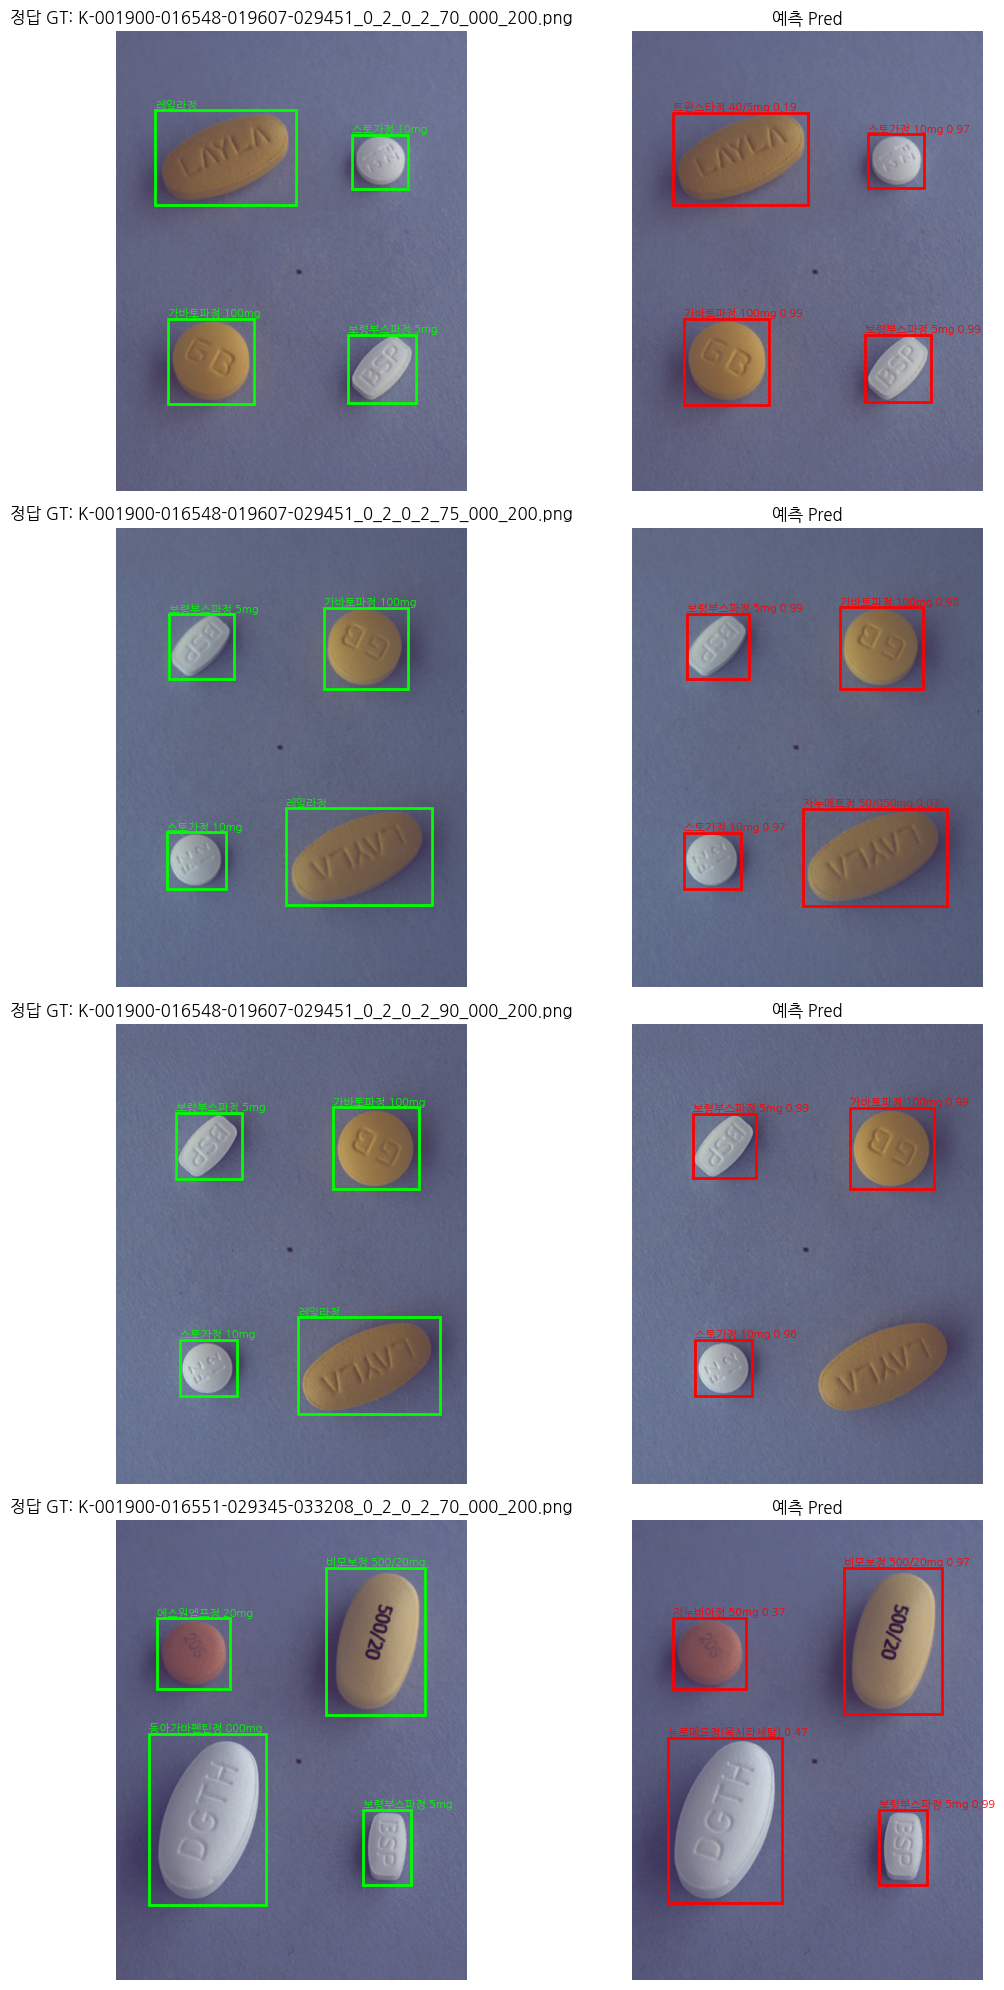

In [20]:
# ============================================================
# 9-2. eval 이미지: 정답 vs 예측 나란히 시각화
# ============================================================
# 한글 폰트 (Colab)
!apt-get -qq install -y fonts-nanum >/dev/null 2>&1
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
from PIL import Image
for fp in fm.findSystemFonts():
    if "Nanum" in fp: fm.fontManager.addfont(fp)
plt.rcParams["font.family"] = "NanumGothic"; plt.rcParams["axes.unicode_minus"] = False

names = model.names   # {0: '보령부스파정 5mg', ...}
img_dir = DATASET_DIR / "images" / "test"
lbl_dir = DATASET_DIR / "labels" / "test"

def gt_boxes(stem, W, H):
    p = lbl_dir / f"{stem}.txt"
    out = []
    if p.exists():
        for line in p.read_text().strip().splitlines():
            c, cx, cy, w, h = map(float, line.split())
            out.append((int(c), (cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H))
    return out

eval_imgs = sorted(img_dir.glob("*.png"))[:4]
fig, axes = plt.subplots(len(eval_imgs), 2, figsize=(12, 5*len(eval_imgs)))
for row, ip in enumerate(eval_imgs):
    img = Image.open(ip).convert("RGB"); W, H = img.size
    # 정답
    ax = axes[row, 0]; ax.imshow(img); ax.set_title(f"정답 GT: {ip.name}"); ax.axis("off")
    for c, x1, y1, x2, y2 in gt_boxes(ip.stem, W, H):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="lime", lw=2))
        ax.text(x1, y1-5, names[c], color="lime", fontsize=8)
    # 예측
    r = model.predict(str(ip), imgsz=640, conf=0.05, max_det=4, device=DEVICE, verbose=False)[0]
    ax = axes[row, 1]; ax.imshow(img); ax.set_title("예측 Pred"); ax.axis("off")
    for (x1,y1,x2,y2), c, s in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.cls.cpu().numpy(), r.boxes.conf.cpu().numpy()):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", lw=2))
        ax.text(x1, y1-5, f"{names[int(c)]} {s:.2f}", color="red", fontsize=8)
plt.tight_layout(); plt.show()